In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Asegura imports desde la raíz del repo (ajusta si tu notebook está en otra carpeta)
ROOT = Path().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = "float32"  # DV suele ser más estable y rápido en float32 en tu repo

torch.manual_seed(0)
if device == "cuda":
    torch.cuda.manual_seed_all(0)

print("device:", device, " dtype:", dtype, " ROOT:", ROOT)


device: cpu  dtype: float32  ROOT: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026


In [3]:
import importlib

import src.trainer.schrodinger_train as sch_train
import src.nn.DVPDESolver as dv_solver_mod

importlib.reload(sch_train)
importlib.reload(dv_solver_mod)

from src.trainer.schrodinger_train import train
from src.nn.DVPDESolver import DVPDESolver

from src.problems.schrodinger import build_eq_params, sanity_check
from src.problems.schrodinger.problem import build_problem
from src.utils.logger import Logging

print("Imports OK.")


Imports OK.


In [4]:
from src.utils.nb_run_logger import NBRunLogger
from pathlib import Path

NOTEBOOK_PATH = Path(r"./prueba_box_dv - copia.ipynb")  # <-- AJUSTA si no está en el mismo folder

run_logger = NBRunLogger("box", "DV", seed=0, tag="pl_box_DV_bq_circ19_e10_w2_2q_2l")
run_logger.attach_python_logging(also_console=True)                 # <- captura los INFO:... del train
run_logger.enable_autosave_figures_each_cell()     # <- guarda figuras aunque no haya plt.show()

print("RUN_DIR:", run_logger.run_dir.resolve())
print("FIG_DIR:", run_logger.fig_dir.resolve())
print("ART_DIR:", run_logger.art_dir.resolve())


RUN_DIR: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\box\DV\20260309-210937_seed0_pl_box_DV_bq_circ19_e10_w2_2q_2l
FIG_DIR: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\box\DV\20260309-210937_seed0_pl_box_DV_bq_circ19_e10_w2_2q_2l\figures
ART_DIR: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\box\DV\20260309-210937_seed0_pl_box_DV_bq_circ19_e10_w2_2q_2l\artifacts


In [5]:
import logging

log_path = run_logger.art_dir / "python.log"

fh = logging.FileHandler(log_path, encoding="utf-8")
fh.setLevel(logging.INFO)
fh.setFormatter(logging.Formatter("%(asctime)s %(levelname)s:%(name)s:%(message)s"))

train_lg = logging.getLogger("src.utils.logger")
# evita duplicar el file handler si ya estaba
if not any(isinstance(h, logging.FileHandler) and getattr(h, "baseFilename", "") == str(log_path) for h in train_lg.handlers):
    train_lg.addHandler(fh)

print("Logging a archivo:", log_path)


Logging a archivo: results\box\DV\20260309-210937_seed0_pl_box_DV_bq_circ19_e10_w2_2q_2l\artifacts\python.log


In [6]:
# --- Pozo infinito (box) ---
eq_params = build_eq_params(
    "box",
    L=1.0,
    T=0.2,         # buen T para que Im no sea pequeña
    n_level=1,     # modo n=1
    mass=1.0,
    hbar=1.0,
    num_grid=800,  # para exact/diagnóstico
)

san = sanity_check(eq_params)
print("eq_params:", eq_params)
print("sanity:", san)


eq_params: {'example': 'box', 'L': 1.0, 'T': 0.2, 'mass': 1.0, 'hbar': 1.0, 'n_level': 1, 'x_min': 0.0, 'x_max': 1.0, 'omega': 1.0, 'V0': 50.0, 'barrier_width': 0.2, 'x_center': 0.5, 'num_grid': 800}
sanity: {'V_min': 0.0, 'V_max': 0.0, 'psi0_norm': 0.9974968671630001, 'psiT_norm': 0.9974968671630003}


In [7]:
args = {
    "eq_params": eq_params,
    "device": device,
    "dtype": dtype,
    "problem": "schrodinger",
    "hard_bc": True,
    "hard_bc_power": 1.0,

    # training
    "epochs": 10
    ,        # smoke razonable; sube a 1500-3000 si quieres
    "lr": 1e-3,
    "batch_size": 64,
    "print_every": 5,

    # pesos base
    "w_pde": 1.0,
    "w_bc":  0.1,        # box necesita BC fuerte (psi=0 en x=0,L)
    "w_ic":  250.0,
    "w_norm": 5.0,

    # NUEVO: ayudar a que Im no se "ignore" (generalmente mejora DV)
    "w_pde_i": 10.0,
    "w_bc_i":  1.0,
    "w_ic_i":  5.0,

    # warmup/curriculum
    "warmup_epochs": 2,
    "ic_grid": True,      # IC sobre malla (más estable)
    "N_norm": 400,
    "N_val": 400,

    # DV (circuito)
    "num_qubits": 2,
    "num_quantum_layers": 2,
    "shots": None,
    "noise": False,
    "encoding": "angle",
    "q_ansatz": "sim_circ_19", # options: "alternating_layer_tdcnot", farhi , sim_circ_15 ,sim_circ_19, sim_circ_5, layered_circuit

    # red híbrida
    "classic_network": [2, 64, 2],  # input=(t,x), hidden=64, output=(Re,Im)

    # performance (MUY recomendado en DV)
    "pde_chunk_size": 64,  # chunk para residual (reduce costo / memoria)
    "l2_every": 5,         # calcula L2 cada 5 épocas (acelera)
}

from pathlib import Path
ckpt_dir = Path(run_logger.run_dir) / "checkpoints"
logger = Logging(str(ckpt_dir), f"box_DV_seed")
model = DVPDESolver(args, logger, device=torch.device(device))
model.args = args
model.draw_quantum_circuit_flag = False  # evita overhead de dibujo

print("DV model built.")


DV model built.


In [8]:
pc = run_logger.log_param_count(model)
print("Trainable params:", pc)


Trainable params: {'total': 652, 'quantum': 8, 'classical': 644}


In [9]:
run_logger.log_config(eq_params=eq_params, args=args)




In [10]:
param_dtype = next(model.parameters()).dtype
param_device = next(model.parameters()).device

t_test = torch.rand(8, 1, device=param_device, dtype=param_dtype) * eq_params["T"]
x_test = torch.rand(8, 1, device=param_device, dtype=param_dtype) * (eq_params["x_max"] - eq_params["x_min"]) + eq_params["x_min"]

y = model(torch.cat([t_test, x_test], dim=1))
print("forward ok ->", y.shape, y.dtype, y.device)


forward ok -> torch.Size([8, 2]) torch.float32 cpu


QNode encontrado en quantum_layer.circuit
0: ─╭AngleEmbedding(M0)──RX(0.61)───RZ(-0.69)─╭||─╭X─╭●──RX(-0.70)──RZ(0.01)─╭||─╭X─╭●─┤  <Z>
1: ─╰AngleEmbedding(M0)──RX(-0.78)──RZ(0.94)──╰||─╰●─╰X──RX(-1.62)──RZ(0.12)─╰||─╰●─╰X─┤  <Z>

M0 = 
tensor([0., 0.])


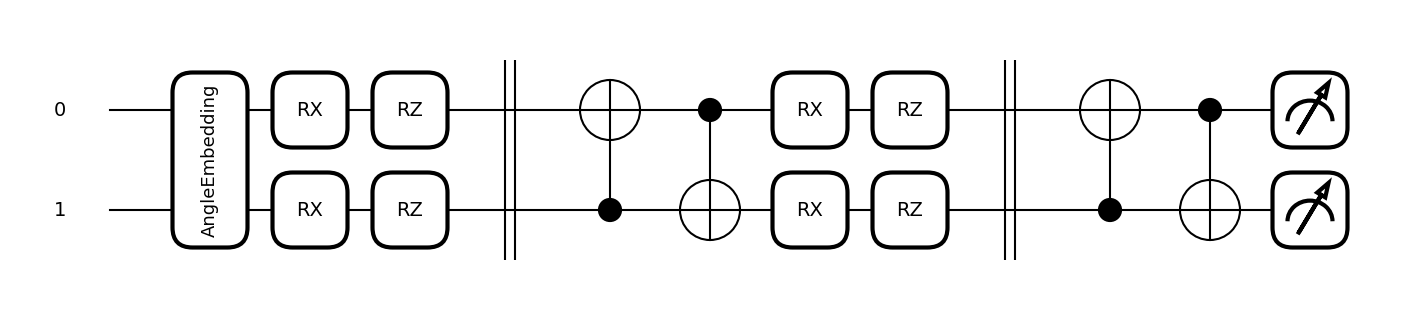

In [11]:
import torch
import pennylane as qml
import matplotlib.pyplot as plt

ql = model.quantum_layer

# Encontrar el QNode (ya viste que está en quantum_layer.circuit)
qnode = getattr(ql, "qnode", None)
if qnode is None:
    for name, val in vars(ql).items():
        if isinstance(val, qml.QNode):
            print(f"QNode encontrado en quantum_layer.{name}")
            qnode = val
            break
if qnode is None:
    raise RuntimeError("No encontré un QNode dentro de model.quantum_layer")

# Input para dibujar (ajusta longitud según tu circuito)
dev = next(model.parameters()).device
dt  = next(model.parameters()).dtype

# Prueba con 4 (tu num_qubits=4); si falla, baja a 2.
n = model.args.get("num_qubits", 4) if hasattr(model, "args") else 4
x_draw = torch.zeros(n, device=dev, dtype=dt)
if n >= 2:
    x_draw[0] = 0.0  # t
    x_draw[1] = 0.0  # x

# 1) ASCII
try:
    drawer_txt = qml.draw(qnode)     # <- sin expansion_strategy
    print(drawer_txt(x_draw))
except Exception as e:
    print("No pude dibujar en ASCII con ese x_draw:", repr(e))
    print("Probando con vector de 2 entradas...")
    x2 = torch.tensor([0.0, 0.0], device=dev, dtype=dt)
    drawer_txt = qml.draw(qnode)
    print(drawer_txt(x2))

# 2) Figura (matplotlib)
try:
    drawer_fig = qml.draw_mpl(qnode) # <- sin expansion_strategy
    fig, ax = drawer_fig(x_draw)
    plt.show()
except Exception as e:
    print("No pude dibujar con draw_mpl con ese x_draw:", repr(e))
    print("Probando con vector de 2 entradas...")
    x2 = torch.tensor([0.0, 0.0], device=dev, dtype=dt)
    drawer_fig = qml.draw_mpl(qnode)
    fig, ax = drawer_fig(x2)
    plt.show()


In [12]:
import logging, sys
from pathlib import Path

def force_live_logging(log_file: Path, level=logging.INFO):
    log_file.parent.mkdir(parents=True, exist_ok=True)

    # 1) Rehabilita logging si alguien lo deshabilitó
    logging.disable(logging.NOTSET)  # equivalente a "no deshabilitar nada"

    # 2) Fuerza configuración nueva (borra handlers previos)
    logging.basicConfig(
        level=level,
        format="%(levelname)s:%(name)s:%(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),                    # notebook live
            logging.FileHandler(log_file, encoding="utf-8"),      # a archivo
        ],
        force=True,  # <-- clave: resetea config previa
    )

    # 3) Asegura que los loggers del proyecto no bloqueen mensajes
    for name in ["src.utils.logger", "src.trainer.schrodinger_train"]:
        lg = logging.getLogger(name)
        lg.setLevel(level)
        lg.propagate = True
        lg.disabled = False

    sys.stdout.flush()

# Usa el mismo python.log que luego parseas
force_live_logging(run_logger.art_dir / "python.log")

# test
logging.getLogger("src.utils.logger").info("TEST: ahora deberías ver esto en el notebook y guardado en python.log")



INFO:src.utils.logger:TEST: ahora deberías ver esto en el notebook y guardado en python.log


In [13]:
import logging

# Evita que src.utils.logger mande mensajes al root *y* a sus propios handlers
lg = logging.getLogger("src.utils.logger")

# 1) borra handlers que ya tuviera ese logger (si tu clase Logging le añadió FileHandler/StreamHandler)
lg.handlers.clear()

# 2) deja que SOLO el root (basicConfig) escriba a consola + archivo
lg.propagate = True
lg.disabled = False
lg.setLevel(logging.INFO)


In [14]:
# tamaños recomendados para DV (no tan grandes al inicio)
train(model, N_f=768, N_b=0, N_0=256)



INFO:src.utils.logger:It: 1, Loss: 2.664e+02, Loss_res: 4.460e-02,  Loss_bcs: 0.000e+00, Loss_ut_ics: 1.046e+00, Loss_norm: 9.987e-01, Loss_gauge: 0.000e+00, w_pde: 5.00e-01, L^2_error: 1.007e+00, lr: 1.000e-03, Time: 2.34e+00
INFO:src.utils.logger:Model state saved to results\box\DV\20260309-210937_seed0_pl_box_DV_bq_circ19_e10_w2_2q_2l\checkpoints\2026-03-09_21-09-37-547455_box_DV_seed\model.pth
INFO:src.utils.logger:Model weights saved to results\box\DV\20260309-210937_seed0_pl_box_DV_bq_circ19_e10_w2_2q_2l\checkpoints\2026-03-09_21-09-37-547455_box_DV_seed\model_weights.pth
INFO:src.utils.logger:It: 5, Loss: 2.408e+02, Loss_res: 2.823e-02,  Loss_bcs: 0.000e+00, Loss_ut_ics: 9.433e-01, Loss_norm: 9.986e-01, Loss_gauge: 0.000e+00, w_pde: 1.00e+00, L^2_error: 9.750e-01, lr: 1.000e-03, Time: 1.00e+01
INFO:src.utils.logger:Model state saved to results\box\DV\20260309-210937_seed0_pl_box_DV_bq_circ19_e10_w2_2q_2l\checkpoints\2026-03-09_21-09-37-547455_box_DV_seed\model.pth
INFO:src.utils

In [15]:
# 1) intenta guardar lo que exista en model.loss_history / model.l2_rel_history
meta = run_logger.log_histories(model)
print("history_meta:", meta)

# 2) esto es lo importante: extrae Loss y L^2_error del LOG REAL (INFO:... It: ...)
parsed = run_logger.parse_schrodinger_train_log()
print("Puntos parseados del log:", len(parsed["it"]))
print("Último it/loss/l2:", parsed["it"][-1], parsed["loss"][-1], parsed["l2"][-1])


history_meta: {'loss_history_len': 10, 'l2_rel_history_len': 10, 'loss_history_type': "<class 'list'>", 'l2_rel_history_type': "<class 'list'>"}
Puntos parseados del log: 3
Último it/loss/l2: 10 213.1 0.9454


In [16]:
def count_trainable_params(m):
    total = sum(p.numel() for p in m.parameters() if p.requires_grad)
    quantum = sum(p.numel() for n, p in m.named_parameters() if ("quantum_layer" in n) and p.requires_grad)
    classical = total - quantum
    return total, quantum, classical

tot, q, c = count_trainable_params(model)
print(f"Trainable params -> total: {tot} | quantum: {q} | classical: {c}")


Trainable params -> total: 652 | quantum: 8 | classical: 644


In [17]:
import torch

device_ = next(model.parameters()).device
dtype_  = next(model.parameters()).dtype
problem = build_problem(eq_params, device=device_, dtype=dtype_)

# grid en x y tiempos
x = torch.linspace(problem["x_min"], problem["x_max"], 400, device=device_, dtype=dtype_).reshape(-1,1)
t0 = torch.zeros_like(x)
tT = torch.full_like(x, float(problem["T"]))

with torch.no_grad():
    psi0 = model(torch.cat([t0, x], dim=1))
    psiT = model(torch.cat([tT, x], dim=1))

# norma (trapz)
prob0 = psi0[:,0]**2 + psi0[:,1]**2
probT = psiT[:,0]**2 + psiT[:,1]**2
norm0 = torch.trapz(prob0, x.squeeze(-1)).item()
normT = torch.trapz(probT, x.squeeze(-1)).item()

# BC: valores en bordes
xL = torch.tensor([[problem["x_min"]],[problem["x_max"]]], device=device_, dtype=dtype_)
tline = torch.linspace(0.0, float(problem["T"]), 200, device=device_, dtype=dtype_).reshape(-1,1)

with torch.no_grad():
    psi_left  = model(torch.cat([tline, torch.full_like(tline, float(problem["x_min"]))], dim=1))
    psi_right = model(torch.cat([tline, torch.full_like(tline, float(problem["x_max"]))], dim=1))

max_left  = torch.sqrt(psi_left[:,0]**2  + psi_left[:,1]**2).max().item()
max_right = torch.sqrt(psi_right[:,0]**2 + psi_right[:,1]**2).max().item()

print("Norm pred t=0:", norm0)
print("Norm pred t=T:", normT)
print("max |psi(t,x_min)|:", max_left)
print("max |psi(t,x_max)|:", max_right)


Norm pred t=0: 0.009693433530628681
Norm pred t=T: 0.009698673151433468
max |psi(t,x_min)|: 0.0
max |psi(t,x_max)|: 0.0


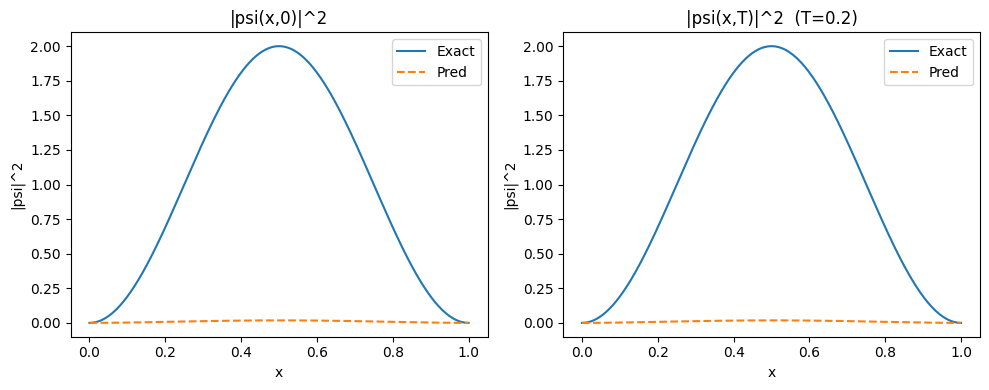

In [18]:
import numpy as np

x_plot = torch.linspace(problem["x_min"], problem["x_max"], 500, device=device_, dtype=dtype_).reshape(-1,1)
t0p = torch.zeros_like(x_plot)
tTp = torch.full_like(x_plot, float(problem["T"]))

with torch.no_grad():
    re0_ex, im0_ex, _ = problem["exact"](problem["n_level"], t0p, x_plot)
    reT_ex, imT_ex, _ = problem["exact"](problem["n_level"], tTp, x_plot)

    y0 = model(torch.cat([t0p, x_plot], dim=1))
    yT = model(torch.cat([tTp, x_plot], dim=1))

re0_pr, im0_pr = y0[:,0:1], y0[:,1:2]
reT_pr, imT_pr = yT[:,0:1], yT[:,1:2]

p0_ex = (re0_ex**2 + im0_ex**2).detach().cpu().numpy().squeeze()
p0_pr = (re0_pr**2 + im0_pr**2).detach().cpu().numpy().squeeze()
pT_ex = (reT_ex**2 + imT_ex**2).detach().cpu().numpy().squeeze()
pT_pr = (reT_pr**2 + imT_pr**2).detach().cpu().numpy().squeeze()

xx = x_plot.detach().cpu().numpy().squeeze()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(xx, p0_ex, label="Exact")
plt.plot(xx, p0_pr, "--", label="Pred")
plt.title("|psi(x,0)|^2")
plt.xlabel("x"); plt.ylabel("|psi|^2"); plt.legend()

plt.subplot(1,2,2)
plt.plot(xx, pT_ex, label="Exact")
plt.plot(xx, pT_pr, "--", label="Pred")
plt.title(f"|psi(x,T)|^2  (T={problem['T']})")
plt.xlabel("x"); plt.ylabel("|psi|^2"); plt.legend()

plt.tight_layout()
plt.show()


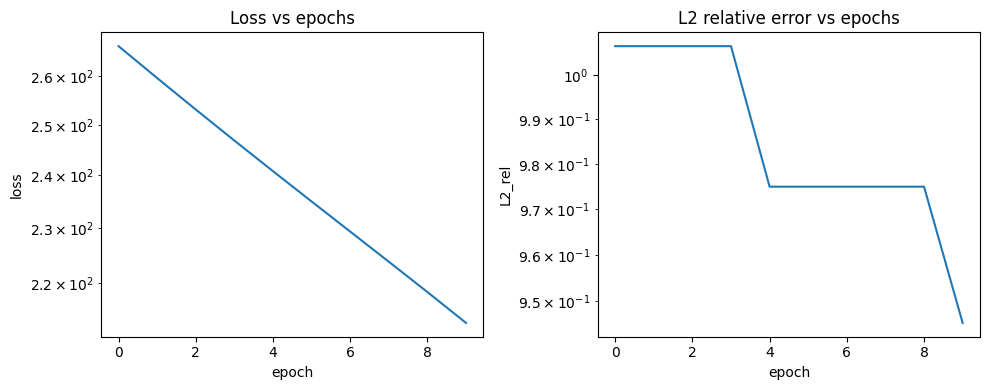

In [19]:
import numpy as np

loss_hist = np.array(getattr(model, "loss_history", []), dtype=float)
l2_hist   = np.array(getattr(model, "l2_rel_history", []), dtype=float)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(loss_hist)
plt.yscale("log")
plt.title("Loss vs epochs")
plt.xlabel("epoch"); plt.ylabel("loss")

plt.subplot(1,2,2)
plt.plot(l2_hist)
plt.yscale("log")
plt.title("L2 relative error vs epochs")
plt.xlabel("epoch"); plt.ylabel("L2_rel")

plt.tight_layout()
plt.show()


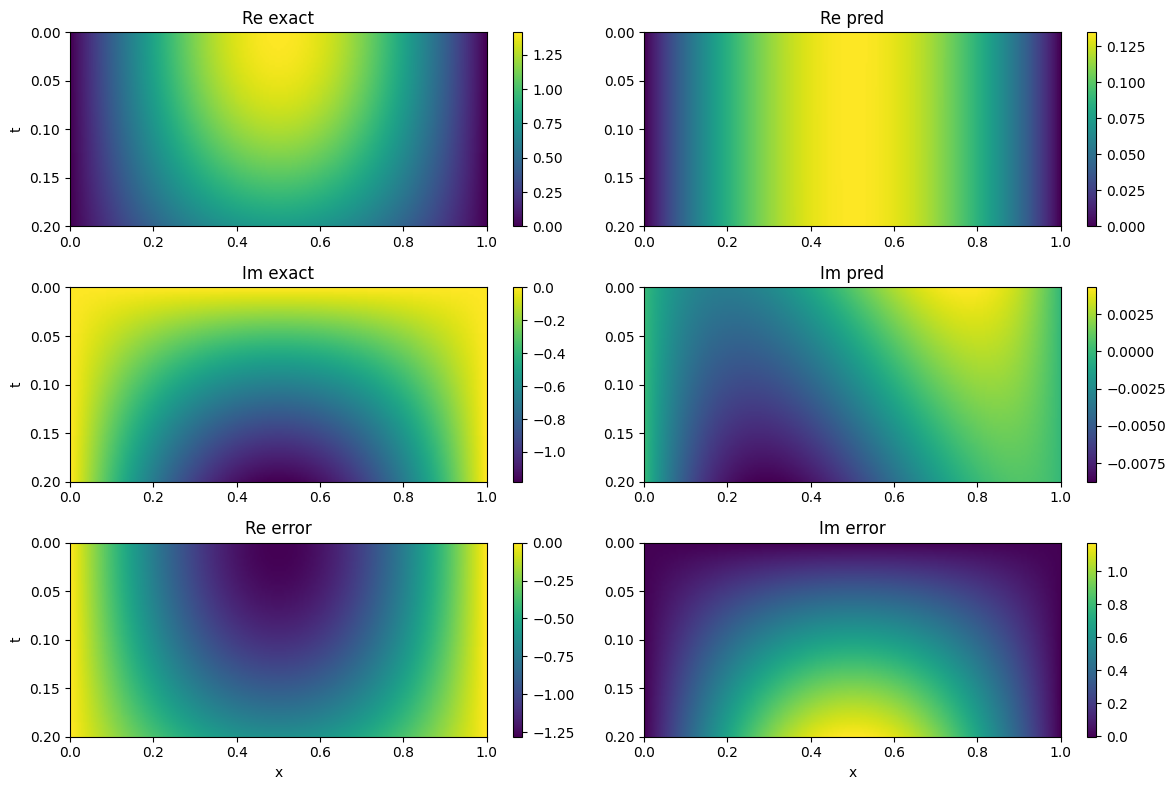

In [20]:
import numpy as np

Nt, Nx = 80, 220
t_grid = torch.linspace(0.0, float(problem["T"]), Nt, device=device_, dtype=dtype_).reshape(-1,1)
x_grid = torch.linspace(problem["x_min"], problem["x_max"], Nx, device=device_, dtype=dtype_).reshape(-1,1)

# mallado tipo (Nt*Nx, 1)
TT = t_grid.repeat(1, Nx).reshape(-1,1)
XX = x_grid.repeat(Nt, 1)

with torch.no_grad():
    re_ex, im_ex, _ = problem["exact"](problem["n_level"], TT, XX)
    y_pr = model(torch.cat([TT, XX], dim=1))
    re_pr, im_pr = y_pr[:,0:1], y_pr[:,1:2]

re_ex = re_ex.reshape(Nt, Nx).detach().cpu().numpy()
im_ex = im_ex.reshape(Nt, Nx).detach().cpu().numpy()
re_pr = re_pr.reshape(Nt, Nx).detach().cpu().numpy()
im_pr = im_pr.reshape(Nt, Nx).detach().cpu().numpy()

re_er = re_pr - re_ex
im_er = im_pr - im_ex

extent = [float(problem["x_min"]), float(problem["x_max"]), float(problem["T"]), 0.0]

plt.figure(figsize=(12,8))

plt.subplot(3,2,1); plt.imshow(re_ex, aspect="auto", extent=extent); plt.title("Re exact"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,2); plt.imshow(re_pr, aspect="auto", extent=extent); plt.title("Re pred");  plt.colorbar()

plt.subplot(3,2,3); plt.imshow(im_ex, aspect="auto", extent=extent); plt.title("Im exact"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,4); plt.imshow(im_pr, aspect="auto", extent=extent); plt.title("Im pred");  plt.colorbar()

plt.subplot(3,2,5); plt.imshow(re_er, aspect="auto", extent=extent); plt.title("Re error"); plt.xlabel("x"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,6); plt.imshow(im_er, aspect="auto", extent=extent); plt.title("Im error"); plt.xlabel("x"); plt.colorbar()

plt.tight_layout()
plt.show()


In [21]:
import json
import csv
from datetime import datetime
from pathlib import Path

import torch

# --- Requiere: model, eq_params, run_logger (y idealmente device/dtype/args si existen) ---
assert "model" in globals(), "No encuentro 'model'. Ejecuta esta celda después de entrenar."
assert "eq_params" in globals(), "No encuentro 'eq_params'."
assert "run_logger" in globals(), "No encuentro 'run_logger'."

# ---------- Utils ----------
def _to_path(x):
    try:
        return Path(x)
    except Exception:
        return Path(str(x))

def _safe_get(d, key, default=None):
    try:
        return d.get(key, default)
    except Exception:
        return default

def _write_json(path: Path, obj: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def _model_eval(model, t, x):
    """Soporta model([t,x]) o model(t,x) según tu API."""
    try:
        return model(torch.cat([t, x], dim=1))
    except Exception:
        return model(t, x)

def _l2_rel_prob(prob_pred: torch.Tensor, prob_exact: torch.Tensor, eps: float = 1e-12) -> float:
    num = torch.sqrt(torch.mean((prob_pred - prob_exact) ** 2))
    den = torch.sqrt(torch.mean(prob_exact ** 2)) + eps
    return (num / den).item()

def _find_results_root_from_run_logger(run_logger):
    """Intenta encontrar carpeta 'results' a partir de run_logger.run_dir; si no, usa ./results."""
    run_dir = _to_path(getattr(run_logger, "run_dir", ".")).resolve()
    # caso 1: alguna carpeta padre se llama "results"
    for p in [run_dir] + list(run_dir.parents):
        if p.name.lower() == "results":
            return p
    # caso 2: algún padre contiene una carpeta llamada "results"
    for p in run_dir.parents:
        cand = p / "results"
        if cand.exists() and cand.is_dir():
            return cand
    # fallback
    return (Path(".") / "results").resolve()

def _append_or_update_csv(csv_path: Path, row: dict, key_col: str = "run_dir"):
    """
    Agrega una fila al CSV. Si ya existe una fila con el mismo key_col (p.ej. run_dir), la reemplaza.
    Funciona sin pandas (solo stdlib).
    """
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    rows = []
    cols = list(row.keys())

    if csv_path.exists():
        with open(csv_path, "r", newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            old_cols = reader.fieldnames or []
            cols = list(dict.fromkeys(old_cols + cols))  # unión preservando orden
            for r in reader:
                rows.append(r)

        # filtra si ya existe esa corrida
        new_rows = []
        for r in rows:
            if r.get(key_col, "") != str(row.get(key_col, "")):
                new_rows.append(r)
        rows = new_rows

    # agrega la fila nueva
    # asegura todas las columnas
    row_filled = {c: row.get(c, "") for c in cols}
    rows.append(row_filled)

    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=cols)
        writer.writeheader()
        writer.writerows(rows)

# ---------- Construye pb / exact ----------
from src.problems.schrodinger.problem import build_problem

# dtype/device robusto
device_val = globals().get("device", "cpu")
dev = torch.device(device_val) if not isinstance(device_val, torch.device) else device_val

dtype_str = str(globals().get("dtype", _safe_get(getattr(model, "args", {}), "dtype", "float64")))
torch_dtype = torch.float64 if "64" in dtype_str else torch.float32

pb = build_problem(eq_params, device=dev, dtype=torch_dtype)

# eval grid
num_x = int(_safe_get(eq_params, "num_grid", 800))
x = torch.linspace(pb["x_min"], pb["x_max"], num_x, device=dev, dtype=pb["dtype"]).reshape(-1, 1)

T = float(pb["T"])
t_fracs = [0.0, 0.25, 0.50, 0.75, 1.0]
t_eval = torch.tensor([f * T for f in t_fracs], device=dev, dtype=pb["dtype"]).reshape(-1, 1)

# Detecta exacta
has_exact = ("exact" in pb) and callable(pb["exact"])

series = []
l2_rel_psi_T = None
l2_rel_prob_T = None

with torch.no_grad():
    for ti in t_eval:
        t = ti.repeat(x.shape[0], 1)
        pred = _model_eval(model, t, x)
        pr, pi = pred[:, 0:1], pred[:, 1:2]

        rec = {"t": float(ti.item())}

        if has_exact:
            er, ei, _ = pb["exact"](pb["n_level"], t, x)

            # L2 relativo de psi (Re+Im)
            l2_abs_psi = torch.sqrt(torch.mean((pr - er) ** 2 + (pi - ei) ** 2))
            ref_psi = torch.sqrt(torch.mean(er ** 2 + ei ** 2)) + 1e-12
            rec["l2_rel_psi"] = float((l2_abs_psi / ref_psi).item())

            # L2 relativo de |psi|^2
            prob_pred = pr ** 2 + pi ** 2
            prob_exact = er ** 2 + ei ** 2
            rec["l2_rel_prob"] = float(_l2_rel_prob(prob_pred, prob_exact))

        series.append(rec)

# extrae T
if has_exact and len(series) > 0:
    l2_rel_psi_T = series[-1].get("l2_rel_psi", None)
    l2_rel_prob_T = series[-1].get("l2_rel_prob", None)

# Boundary check (genérico: xmin/xmax)
ts = torch.linspace(0.0, T, 20, device=dev, dtype=pb["dtype"]).reshape(-1, 1)
x_min = torch.full_like(ts, float(pb["x_min"]))
x_max = torch.full_like(ts, float(pb["x_max"]))

with torch.no_grad():
    psi_min = _model_eval(model, ts, x_min)
    psi_max = _model_eval(model, ts, x_max)

bdry_xmin = torch.sqrt(psi_min[:, 0] ** 2 + psi_min[:, 1] ** 2).max().item()
bdry_xmax = torch.sqrt(psi_max[:, 0] ** 2 + psi_max[:, 1] ** 2).max().item()

# ---------- Metadata (reutilizable en todos) ----------
args = globals().get("args", getattr(model, "args", {})) or {}
potential = str(getattr(run_logger, "problem", _safe_get(eq_params, "potential", _safe_get(eq_params, "name", "unknown"))))
solver = str(getattr(run_logger, "solver", getattr(run_logger, "solver_type", _safe_get(args, "solver_type", "unknown"))))
seed = getattr(run_logger, "seed", _safe_get(args, "seed", None))
tag = getattr(run_logger, "tag", _safe_get(args, "tag", ""))

run_dir = _to_path(getattr(run_logger, "run_dir", ".")).resolve()
art_dir = _to_path(getattr(run_logger, "art_dir", run_dir / "artifacts")).resolve()

# parámetros entrenables (total)
n_params_total = int(sum(p.numel() for p in model.parameters() if p.requires_grad))

# si existe una función de conteo detallado (DV notebooks), úsala
n_params_quantum = ""
n_params_classical = ""
if "count_trainable_params" in globals() and callable(globals()["count_trainable_params"]):
    try:
        out = globals()["count_trainable_params"](model)
        if isinstance(out, dict):
            n_params_total = int(out.get("total", n_params_total))
            n_params_quantum = int(out.get("quantum", ""))
            n_params_classical = int(out.get("classical", ""))
        elif isinstance(out, (tuple, list)) and len(out) >= 3:
            n_params_total = int(out[0])
            n_params_quantum = int(out[1])
            n_params_classical = int(out[2])
    except Exception:
        pass

# identifica arquitectura / ansatz / encoding (sin forzar que existan)
classic_network = _safe_get(args, "classic_network", "")
num_qubits = _safe_get(args, "num_qubits", "")
num_layers = _safe_get(args, "num_quantum_layers", _safe_get(args, "num_layers", ""))
q_ansatz = _safe_get(args, "q_ansatz", "")
encoding = _safe_get(args, "encoding", "")

arch_repr = ""
if q_ansatz or num_qubits or num_layers:
    arch_repr = f"DV(q={num_qubits}, L={num_layers}, ansatz={q_ansatz}, enc={encoding}, classic={classic_network})"
else:
    arch_repr = f"PINN(classic={classic_network})"

# epochs/lr y puntos si están disponibles (si no, quedan vacíos)
epochs = _safe_get(args, "epochs", "")
lr = _safe_get(args, "lr", "")
N_f = globals().get("N_f", _safe_get(args, "N_f", ""))
N_b = globals().get("N_b", _safe_get(args, "N_b", ""))
N_0 = globals().get("N_0", _safe_get(args, "N_0", ""))

# ---------- Guardado JSON en artifacts ----------
metrics = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "potential": potential,
    "solver": solver,
    "seed": seed,
    "tag": tag,
    "run_dir": str(run_dir),
    "art_dir": str(art_dir),
    "dtype": dtype_str,
    "device": str(dev),

    "n_params_total": n_params_total,
    "n_params_quantum": n_params_quantum,
    "n_params_classical": n_params_classical,

    "epochs": epochs,
    "lr": lr,
    "N_f": N_f,
    "N_b": N_b,
    "N_0": N_0,

    "arch_repr": arch_repr,
    "classic_network": str(classic_network),
    "num_qubits": str(num_qubits),
    "num_quantum_layers": str(num_layers),
    "q_ansatz": str(q_ansatz),
    "encoding": str(encoding),

    # --- métricas mínimas tesis ---
    "has_exact": bool(has_exact),
    "l2_rel_psi_T": l2_rel_psi_T,
    "l2_rel_prob_T": l2_rel_prob_T,
    "bdry_max_abs_psi_xmin": float(bdry_xmin),
    "bdry_max_abs_psi_xmax": float(bdry_xmax),

    # evidencia temporal
    "series": series,
}

art_dir.mkdir(parents=True, exist_ok=True)
metrics_path = art_dir / "metrics_min.json"
_write_json(metrics_path, metrics)

# ---------- CSV global reutilizable ----------
results_root = _find_results_root_from_run_logger(run_logger)
summary_csv = results_root / "summary" / "summary_runs.csv"

row = {
    "timestamp": metrics["timestamp"],
    "potential": metrics["potential"],
    "solver": metrics["solver"],
    "seed": metrics["seed"],
    "tag": metrics["tag"],
    "run_dir": metrics["run_dir"],
    "n_params_total": metrics["n_params_total"],
    "n_params_quantum": metrics["n_params_quantum"],
    "n_params_classical": metrics["n_params_classical"],
    "epochs": metrics["epochs"],
    "lr": metrics["lr"],
    "N_f": metrics["N_f"],
    "N_b": metrics["N_b"],
    "N_0": metrics["N_0"],
    "dtype": metrics["dtype"],
    "device": metrics["device"],
    "arch_repr": metrics["arch_repr"],
    "q_ansatz": metrics["q_ansatz"],
    "encoding": metrics["encoding"],
    "num_qubits": metrics["num_qubits"],
    "num_quantum_layers": metrics["num_quantum_layers"],
    "classic_network": metrics["classic_network"],
    "has_exact": metrics["has_exact"],
    "l2_rel_psi_T": metrics["l2_rel_psi_T"],
    "l2_rel_prob_T": metrics["l2_rel_prob_T"],
    "bdry_max_abs_psi_xmin": metrics["bdry_max_abs_psi_xmin"],
    "bdry_max_abs_psi_xmax": metrics["bdry_max_abs_psi_xmax"],
    "metrics_json": str(metrics_path),
}

_append_or_update_csv(summary_csv, row, key_col="run_dir")

print("\n[OK] Guardado:")
print(" - metrics_min.json:", metrics_path.resolve())
print(" - summary CSV     :", summary_csv.resolve())
print("\nResumen (t=T):")
print(" - L2_rel(psi)      :", row["l2_rel_psi_T"])
print(" - L2_rel(|psi|^2)  :", row["l2_rel_prob_T"])
print(" - max|psi|(xmin)   :", row["bdry_max_abs_psi_xmin"])
print(" - max|psi|(xmax)   :", row["bdry_max_abs_psi_xmax"])


[OK] Guardado:
 - metrics_min.json: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\box\DV\20260309-210937_seed0_pl_box_DV_bq_circ19_e10_w2_2q_2l\artifacts\metrics_min.json
 - summary CSV     : C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\summary\summary_runs.csv

Resumen (t=T):
 - L2_rel(psi)      : 0.9454045295715332
 - L2_rel(|psi|^2)  : 0.9905499815940857
 - max|psi|(xmin)   : 0.0
 - max|psi|(xmax)   : 0.0


In [22]:
import torch.nn as nn

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def n_linear_layers(mod):
    return sum(1 for m in mod.modules() if isinstance(m, nn.Linear))

def dv_report(model):
    # --- info básica ---
    classic_net = model.args.get("classic_network", None)
    hidden = classic_net[-2] if classic_net is not None and len(classic_net) >= 2 else None

    nq = model.num_qubits
    nl = model.quantum_layer.num_quantum_layers

    qshape = tuple(model.quantum_layer.params.shape)
    qtot = int(model.quantum_layer.params.numel())

    total = int(count_trainable_params(model))
    classical = total - qtot

    print("classic_network:", classic_net, "| hidden:", hidden)
    print("num_qubits:", nq, "| num_layers:", nl)
    print("quantum params shape:", qshape, "| quantum total:", qtot)
    print("classical total:", classical, "| TOTAL trainable:", total)
    print("Linear(pre):", n_linear_layers(model.preprocessor), "| Linear(post):", n_linear_layers(model.postprocessor))

# Uso:
dv_report(model)

classic_network: [2, 64, 2] | hidden: 64
num_qubits: 2 | num_layers: 2
quantum params shape: (2, 4) | quantum total: 8
classical total: 644 | TOTAL trainable: 652
Linear(pre): 2 | Linear(post): 2
